In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import zipfile
import os
import time
import shutil
from torchsummary import summary
import io
import pandas as pd

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [3]:
class AlexNet(nn.Module):
  def __init__(self, num_classes = 3):
    super(AlexNet, self).__init__()

    # Capa 1
    self.conv1 = nn.Conv2d(3, 96, kernel_size = 11, stride = 4, padding = 0)
    self.relu1 = nn.ReLU(inplace = True)
    self.pool1 = nn.MaxPool2d(kernel_size = 3, stride = 2)

    # Capa 2
    self.conv2 = nn.Conv2d(96, 256, kernel_size = 5, stride = 1, padding = 2)
    self.relu2 = nn.ReLU(inplace = True)
    self.pool2 = nn.MaxPool2d(kernel_size = 3, stride = 2)

    # Capa 3
    self.conv3 = nn.Conv2d(256, 384, kernel_size = 3, stride = 1, padding = 1)
    self.relu3 = nn.ReLU(inplace = True)

    # Capa 4
    self.conv4 = nn.Conv2d(384, 384, kernel_size = 3, stride = 1, padding = 1)
    self.relu4 = nn.ReLU(inplace = True)

    # Capa 5
    self.conv5 = nn.Conv2d(384, 256, kernel_size = 3, stride = 1, padding = 1)
    self.relu5 = nn.ReLU(inplace = True)
    self.pool5 = nn.MaxPool2d(kernel_size = 3, stride = 2)

    # Capas completamente conectadas (Capas 6, 7 y 8)
    # Capa 6
    self.fc6 = nn.Linear(9216, 4096)    # self.fc6 = nn.Linear(256*6*6, 4096)
    self.relu6 = nn.ReLU(inplace = True)
    self.drop6 = nn.Dropout(p = 0.5)

    # Capa 7
    self.fc7 = nn.Linear(4096, 4096)
    self.relu7 = nn.ReLU(inplace = True)
    self.drop7 = nn.Dropout(p = 0.5)

    # Capa 8
    self.fc8 = nn.Linear(4096, num_classes)

  def forward(self, x):
    # Bloque 1
    x1 = self.conv1(x)
    x2 = self.relu1(x1)
    x3 = self.pool1(x2)

    # Bloque 2
    x4 = self.conv2(x3)
    x5 = self.relu2(x4)
    x6 = self.pool2(x5)

    # Bloque 3
    x7 = self.conv3(x6)
    x8 = self.relu3(x7)

    # Bloque 4
    x9 = self.conv4(x8)
    x10 = self.relu4(x9)

    # Bloque 5
    x11 = self.conv5(x10)
    x12 = self.relu5(x11)
    x13 = self.pool5(x12)

    # Aplanar (Bloque de características)
    x14 = x13.view(x.size(0), 256 * 6 * 6)

    # FC6
    x15 = self.fc6(x14)
    x16 = self.relu6(x15)
    x17 = self.drop6(x16)

    # FC7
    x18 = self.fc7(x17)
    x19 = self.relu7(x18)
    x20 = self.drop7(x19)

    # FC8 (sin softmax, normalmente en el criterio de pérdida) (softmas cuando se evalue el AlexNet)
    x21 = self.fc8(x20)

    return x21



In [4]:
modelo = AlexNet()
modelo = modelo.to(device)

Se sube el folder "Base" con las siguientes características:

*   Las imágenes en .jpg con resolución 256x256
*   El archivo .csv (label)

In [6]:
from google.colab import files
uploaded = files.upload()

Saving BaseDatos.zip to BaseDatos.zip


In [7]:
datos = zipfile.ZipFile(io.BytesIO(uploaded['BaseDatos.zip']))  # BaseDatos.zip
datos.extractall("imagenes/")

In [8]:
root = "imagenes/BaseDatos/Imagenes"
img_list = os.listdir(root)
print(len(img_list))

1311


In [9]:
basedatos = pd.read_csv("imagenes/BaseDatos/dataFiles.csv")
basedatos = basedatos[['Nombre', 'Categoria']]
print(basedatos)

                Nombre  Categoria
0         GATO (1).jpg          2
1       GATO (484).jpg          2
2       GATO (485).jpg          2
3       GATO (486).jpg          2
4       GATO (487).jpg          2
...                ...        ...
1306  ZAPATO (735).jpg          0
1307  ZAPATO (736).jpg          0
1308  ZAPATO (737).jpg          0
1309  ZAPATO (738).jpg          0
1310  ZAPATO (739).jpg          0

[1311 rows x 2 columns]


In [10]:
!rm -rf datos
!mkdir datos && mkdir datos/perros && mkdir datos/gatos && mkdir datos/zapatos

In [13]:
s0 = 0  # contador para gatos
s1 = 0  # contador para perros
s2 = 0  # contador para zapatos
num = 1311  # len(img_list)

for i, (_, i_row) in enumerate(basedatos.iterrows()):
  # Categoría 2 = Gatos
  if i_row['Categoria'] == 2 and s0 < num:
    s0 += 1
    shutil.copyfile('imagenes/BaseDatos/Imagenes/'+i_row['Nombre'], 'datos/gatos/'+i_row['Nombre'])

  # Categoría 1 = Perros
  elif i_row['Categoria'] == 1 and s1 < num:
    s1 += 1
    shutil.copyfile('imagenes/BaseDatos/Imagenes/'+i_row['Nombre'], 'datos/perros/'+i_row['Nombre'])

  # Categoría 0 = Zapatos
  elif i_row['Categoria'] == 0 and s2 < num:
    s2 += 1
    shutil.copyfile('imagenes/BaseDatos/Imagenes/'+i_row['Nombre'], 'datos/zapatos/'+i_row['Nombre'])

  # Verificar si ya se han copiado suficientes imágenes de cada categoría
  if s0 == num and s1 == num and s2 == num:
    break

In [23]:
# Obtener la lista de imágenes desde las 3 clases
img_list = os.listdir('datos/perros/')
img_list.extend(os.listdir('datos/gatos/'))
img_list.extend(os.listdir('datos/zapatos/'))

# Eliminar la carpeta ipynb_checkpoints si existe
!rm -rf 'datos/ipynb_checkpoints/'

# Definir transformaciones: conversión a tensor, resize y normalización
transformar = transforms.Compose([
  transforms.ToTensor(),
  transforms.Resize((256,256)),
  transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Para el triplete RGB
                        std=[0.229, 0.224, 0.225])
  ])

# Cargar dataset con ImageFolder
clases = datasets.ImageFolder('datos', transform=transformar)

# Separar el dataset en entrenamiento y test (80%-20%)
train_size = int(len(img_list)*0.8)
test_size = len(img_list) - train_size
entrenamiento, testeo = torch.utils.data.random_split(clases, [train_size, test_size])

# Crear dataloaders para batch y shuffle
cargar_entrenamiento = torch.utils.data.DataLoader(entrenamiento, batch_size=32, shuffle=True)
cargar_testeo = torch.utils.data.DataLoader(testeo, batch_size=32, shuffle=True)

print(cargar_testeo)

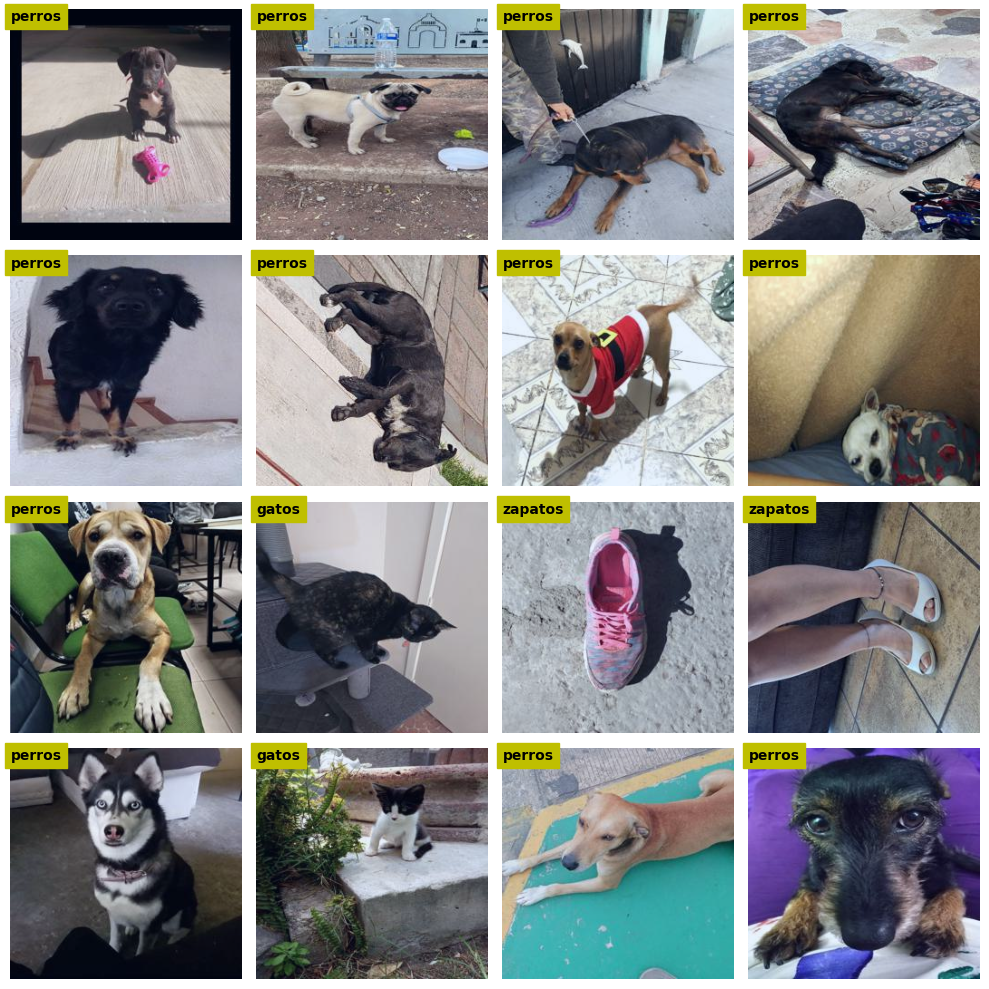

In [24]:
# Obtener un batch de datos del cargador de entrenamiento
x, y = next(iter(cargar_entrenamiento))

# Crear una figura con una cuadrícula de 4x4 imágenes
fig, axs = plt.subplots(4, 4, figsize=(10,10))

# Iterar sobre los ejes creados en el grid
for i, ax in enumerate(axs.flatten()):
    # Permutar las dimensiones del tensor para (Alto, Ancho, Canales) y convertir a numpy
    pic = x[i].permute(1, 2, 0).numpy()

    # Normalizar la imagen para mostrarla adecuadamente
    pic = pic - pic.min()
    pic = pic / pic.max()

    # Obtener la etiqueta correspondiente a partir del índice
    label = clases.classes[y[i]]

    # Mostrar la imagen
    ax.imshow(pic)

    # Añadir el texto con la etiqueta en la esquina superior izquierda
    ax.text(0, 0, label, ha='left', va='top', fontweight='bold',
            color='k', backgroundcolor='y')

    # Ocultar los ejes
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
from torchsummary import summary

model = AlexNet()
summary(model, (3, 224, 224))

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
# Definir el optimizador y el criterio de pérdida
optimizador = optim.Adam(modelo.parameters(), lr=0.0001)  # Adam: Gradiente adaptable
criterio = nn.CrossEntropyLoss()  # Función de pérdida de entropía cruzada

# Número de épocas de entrenamiento
epocas = 100

# Lista para almacenar el error promedio por época
errores_entrenamiento = []

for epoca in range(epocas):
    # Inicializar el error total por época
    error_total = 0

    # Entrenamiento (forward, backward, step)
    for idx, (imagenes, etiquetas) in enumerate(cargar_entrenamiento):
        # Mover datos a GPU si está disponible
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        # Inicializar el gradiente a cero antes del forward-backward
        optimizador.zero_grad()

        # Paso forward: obtener predicciones del modelo
        prediccion = modelo(imagenes)

        # Calcular el error (pérdida) entre las predicciones y las etiquetas reales
        error = criterio(prediccion, etiquetas)

        # Acumular el error total
        error_total += error.item()

        # Backward: calcular gradientes
        error.backward()

        # Actualizar parámetros del modelo
        optimizador.step()

    # Calcular el error promedio de la época
    error_promedio = error_total / (idx + 1)
    errores_entrenamiento.append(error_promedio)

    # Imprimir el error de entrenamiento de la época actual
    print(f'Época: {epoca} | Error de entrenamiento: {error_promedio:.4f}')

    # Validación (o testeo) en cada época, sin cálculo de gradientes
    with torch.no_grad():
        error_testeo_total = 0
        contador_batch_testeo = 0
        for img_test, lbl_test in cargar_testeo:
            img_test, lbl_test = img_test.to(device), lbl_test.to(device)
            salida = modelo(img_test)
            error_testeo = criterio(salida, lbl_test)
            error_testeo_total += error_testeo.item()
            contador_batch_testeo += 1

        error_testeo_promedio = error_testeo_total / contador_batch_testeo
        print(f'Época: {epoca} | Error de test: {error_testeo_promedio:.4f}')

# Graficar la evolución del error de entrenamiento
plt.figure(figsize=(10,6))
plt.plot(errores_entrenamiento, label='Error de Entrenamiento')
plt.title('Evolución del Error de Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

Época: 0 | Error de entrenamiento: 1.0975
Época: 0 | Error de test: 1.0842
Época: 1 | Error de entrenamiento: 1.0893
Época: 1 | Error de test: 1.0863
Época: 2 | Error de entrenamiento: 1.0669
Época: 2 | Error de test: 1.0206
Época: 3 | Error de entrenamiento: 1.0422
Época: 3 | Error de test: 0.9782
Época: 4 | Error de entrenamiento: 0.9817
Época: 4 | Error de test: 0.9336
Época: 5 | Error de entrenamiento: 0.9255
Época: 5 | Error de test: 0.8910
Época: 6 | Error de entrenamiento: 0.9052
Época: 6 | Error de test: 0.8737
Época: 7 | Error de entrenamiento: 0.9161
Época: 7 | Error de test: 0.9098
Época: 8 | Error de entrenamiento: 0.8217
Época: 8 | Error de test: 0.8912
Época: 9 | Error de entrenamiento: 0.7635
Época: 9 | Error de test: 0.9295
Época: 10 | Error de entrenamiento: 0.7809


In [ ]:
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Obtener un batch del cargador de test
xx, yy = next(iter(cargar_testeo))

# Mover imágenes y etiquetas a device (GPU si está disponible)
xx = xx.to(device)
yy = yy.to(device)

# Deshabilitar gradientes para la fase de test
with torch.no_grad():
    # Obtener las predicciones del modelo
    pre_test = torch.argmax(modelo(xx), dim=1)

# Crear figura con una cuadricula de 5x5 imágenes
fig, axs = plt.subplots(5, 5, figsize=(7,7))

for i, ax in enumerate(axs.flatten()):
    # Convertir imagen a formato numpy para visualizar
    # Primero permutar a (H, W, C) y luego pasar a CPU y numpy
    PIC = xx[i].permute(1,2,0).cpu().numpy()

    # Normalizar la imagen para visualizarla adecuadamente
    PIC = PIC - PIC.min()
    PIC = PIC / PIC.max()

    # Obtener la predicción y la etiqueta real
    prediccion_label = clases.classes[pre_test[i]]
    etiqueta_real = clases.classes[yy[i]]

    # Título con predicción y valor real
    title = f'Pred: {prediccion_label}\nTrue: {etiqueta_real}'
    color_title = 'green' if prediccion_label == etiqueta_real else 'red'

    # Mostrar la imagen y el título
    ax.imshow(PIC)
    ax.set_title(title, color=color_title, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()